# 02 — Extracción del Tensor CSI Complejo

**Objetivo**: preparar el tensor CSI complejo (amplitud + fase) a partir del dataset
filtrado generado en `01_EDA.ipynb`, y exportar los splits train/val/test listos
para el entrenamiento de un Fourier Neural Operator (FNO).

---

### ¿Por qué preservar la fase?

Según el informe de referencia (*CV-3DCNN*, §"The Complex-Valued CSI Tensor"):
- Los modelos que usan **solo magnitud** destruyen la información de fase.
- La fase codifica la **directionalidad angular** de las ondas EM (multipath).
- Redes complejas (CV-3DCNN) mejoran ~6 dB frente a modelos magnitud-only.
- **Conclusión**: nunca trabajar solo con `|R|`, siempre con `Re + j·Im`.

### Tensor de entrada
```
R  :  (N_t, N_f, N_tx, N_rx, N_ant)   dtype=complex64
       N_tx=2, N_rx=2, N_ant=4
```

### Contenido del notebook
1. Carga y validación
2. Inspección de la fase
3. Normalización (`maxabs`, preserva fase)
4. CIR — Canal en dominio de retardo
5. Split temporal train / val / test
6. Guardado y resumen de shapes

In [1]:
# ─── Setup ────────────────────────────────────────────────────────────────────

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
ROOT_DIR     = NOTEBOOK_DIR.parent
SRC_DIR      = ROOT_DIR / 'src'
DATA_PROC    = ROOT_DIR / 'data' / 'processed'
NPZ_PATH     = DATA_PROC / 'data_filtered_77.6ghz.npz'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from csi_tensor import (
    load_csi_from_npz,
    normalize_csi,
    denormalize_csi,
    split_train_val_test,
    to_real_imag_stack,
    from_real_imag_stack,
    compute_cir,
    save_csi_splits,
    print_csi_report,
)

print(f'NPZ path : {NPZ_PATH}')
print(f'Existe   : {NPZ_PATH.exists()}')

NPZ path : c:\Users\carlos\Documents\cosas_carlos\TFG\mi_proyecto_ut\data\processed\data_filtered_77.6ghz.npz
Existe   : True


## 1. Carga y validación del tensor

In [2]:
data = load_csi_from_npz(NPZ_PATH)

R    = data['R']
freq = data['frequency']
ts   = data['timestamps']

N_t, N_f, N_tx, N_rx, N_ant = R.shape

print('─' * 50)
print('Tensor R')
print(f'  shape  : {R.shape}')
print(f'  dtype  : {R.dtype}')
print(f'  |R|max : {np.abs(R).max():.4f}')
print(f'  |R|min : {np.abs(R).min():.6f}')
print()
print('Frecuencias')
print(f'  N_f    : {N_f}')
print(f'  min    : {freq.min()*1e-9:.4f} GHz')
print(f'  max    : {freq.max()*1e-9:.4f} GHz')
print(f'  BW     : {(freq.max()-freq.min())*1e-6:.2f} MHz')
print()
print('Tiempo')
print(f'  N_t    : {N_t}')
print(f'  t0     : {ts[0]:.2f} s')
print(f'  t_end  : {ts[-1]:.2f} s')
print(f'  dur    : {ts[-1]-ts[0]:.2f} s')
print('─' * 50)

# Integridad: Re² + Im² == |R|²
err = np.abs(R.real**2 + R.imag**2 - np.abs(R)**2).max()
assert err < 1e-5, f'Integridad Re/Im fallida: err={err}'
print(f'✓ Integridad Re²+Im²=|R|²  (err_max={err:.2e})')

──────────────────────────────────────────────────
Tensor R
  shape  : (549, 870, 2, 2, 4)
  dtype  : complex64
  |R|max : 0.0009
  |R|min : 0.000000

Frecuencias
  N_f    : 870
  min    : 77.6022 GHz
  max    : 81.0000 GHz
  BW     : 3397.85 MHz

Tiempo
  N_t    : 549
  t0     : 1773245231677327360.00 s
  t_end  : 1773245291759347712.00 s
  dur    : 60082020352.00 s
──────────────────────────────────────────────────
✓ Integridad Re²+Im²=|R|²  (err_max=1.71e-13)


## 2. Inspección de la fase

Verificamos que la fase (**ángulo** del número complejo) está distribuida
de forma uniforme en `[-π, π]` — señal de que el tensor no ha sido
pre-procesado en magnitud y que el contenido de fase es rico.

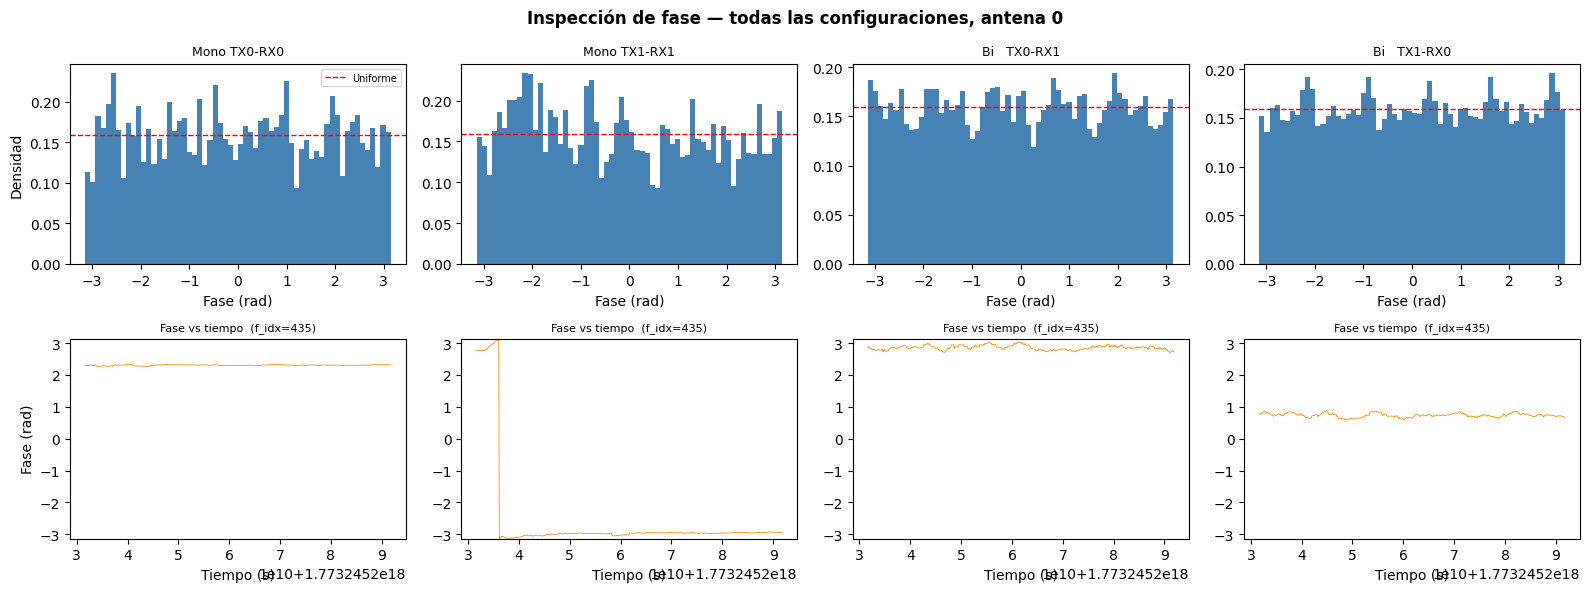

In [3]:
# Configuraciones para visualizar
CONFIGS = [
    (0, 0, 'Mono TX0-RX0'),
    (1, 1, 'Mono TX1-RX1'),
    (0, 1, 'Bi   TX0-RX1'),
    (1, 0, 'Bi   TX1-RX0'),
]
ANT = 0   # antena receptora

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Inspección de fase — todas las configuraciones, antena 0', fontsize=12, fontweight='bold')

for col, (tx, rx, label) in enumerate(CONFIGS):
    R_sel = R[:, :, tx, rx, ANT]   # (N_t, N_f)
    phase = np.angle(R_sel)         # (N_t, N_f)  rad ∈ [-π, π]

    # Histograma de fase (todas las muestras)
    ax_hist = axes[0, col]
    ax_hist.hist(phase.ravel(), bins=60, color='steelblue', edgecolor='none', density=True)
    ax_hist.set_title(label, fontsize=9)
    ax_hist.set_xlabel('Fase (rad)')
    ax_hist.set_ylabel('Densidad' if col == 0 else '')
    ax_hist.axhline(1 / (2 * np.pi), color='red', ls='--', lw=1, label='Uniforme')
    if col == 0:
        ax_hist.legend(fontsize=7)

    # Evolución temporal de la fase en la subportadora central
    f_mid = N_f // 2
    ax_time = axes[1, col]
    ax_time.plot(ts, phase[:, f_mid], lw=0.6, color='darkorange')
    ax_time.set_title(f'Fase vs tiempo  (f_idx={f_mid})', fontsize=8)
    ax_time.set_xlabel('Tiempo (s)')
    ax_time.set_ylabel('Fase (rad)' if col == 0 else '')
    ax_time.set_ylim(-np.pi, np.pi)

plt.tight_layout()
plt.show()

## 3. Normalización

Usamos el modo `'maxabs'`:
- Divide todo el tensor por su valor absoluto máximo.
- El resultado satisface `|R_norm| ∈ [0, 1]`.
- **La fase queda intacta** (solo escala la magnitud global).

Comparamos visualmente la distribución de Re e Im antes y después.

In [4]:
R_norm, norm_meta = normalize_csi(R, mode='maxabs')

print(f'Modo normalización : {norm_meta["mode"]}')
print(f'Escala aplicada    : {norm_meta["scale"]:.6f}')
print(f'|R_norm|.max()     : {np.abs(R_norm).max():.6f}  (debe ser ≈ 1.0)')
print(f'|R_norm|.min()     : {np.abs(R_norm).min():.8f}')
print()

# Verificación de que la fase es idéntica
phase_orig = np.angle(R[:, :, 0, 0, ANT])
phase_norm = np.angle(R_norm[:, :, 0, 0, ANT])
phase_err  = np.abs(phase_orig - phase_norm).max()
print(f'✓ Error máx en fase tras normalización: {phase_err:.2e}  (debe ser ≈ 0)')

Modo normalización : maxabs
Escala aplicada    : 0.000934
|R_norm|.max()     : 1.000000  (debe ser ≈ 1.0)
|R_norm|.min()     : 0.00004983

✓ Error máx en fase tras normalización: 2.38e-07  (debe ser ≈ 0)


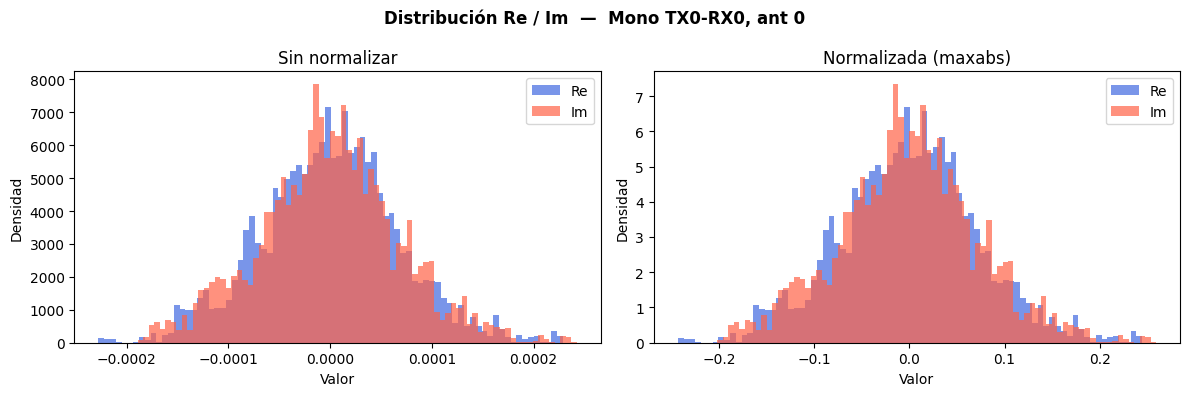

In [5]:
# Distribución Re e Im antes / después de normalizar
tx_plot, rx_plot = 0, 0
R_sel_raw  = R[:, :, tx_plot, rx_plot, ANT]
R_sel_norm = R_norm[:, :, tx_plot, rx_plot, ANT]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribución Re / Im  —  Mono TX0-RX0, ant 0', fontsize=12, fontweight='bold')

for ax, (data_r, label) in zip(axes, [(R_sel_raw, 'Sin normalizar'), (R_sel_norm, 'Normalizada (maxabs)')]):
    ax.hist(data_r.real.ravel(), bins=80, alpha=0.7, color='royalblue', label='Re', density=True)
    ax.hist(data_r.imag.ravel(), bins=80, alpha=0.7, color='tomato',    label='Im', density=True)
    ax.set_title(label)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend()

plt.tight_layout()
plt.show()

## 4. CIR — Canal en dominio de retardo

La **Channel Impulse Response (CIR)** se obtiene mediante IFFT del CFR
complejo. Muestra la potencia recibida en función del retardo de propagación
(τ), codificando la estructura multipath del entorno.

Este es el dominio físico clave del **Ugly Twin**: los taps del CIR
representan los reflectores del escenario indoor.

In [6]:
# Calculamos CIR sobre el tensor normalizado
cir, tau = compute_cir(R_norm, freq, window=True)

print(f'CIR shape  : {cir.shape}')
print(f'tau[0]     : {tau[0]*1e9:.3f} ns')
print(f'tau[-1]    : {tau[-1]*1e9:.3f} ns')
print(f'Resolución : {(tau[1]-tau[0])*1e9:.3f} ns/tap')

CIR shape  : (549, 870, 2, 2, 4)
tau[0]     : 0.000 ns
tau[-1]    : 255.750 ns
Resolución : 0.294 ns/tap


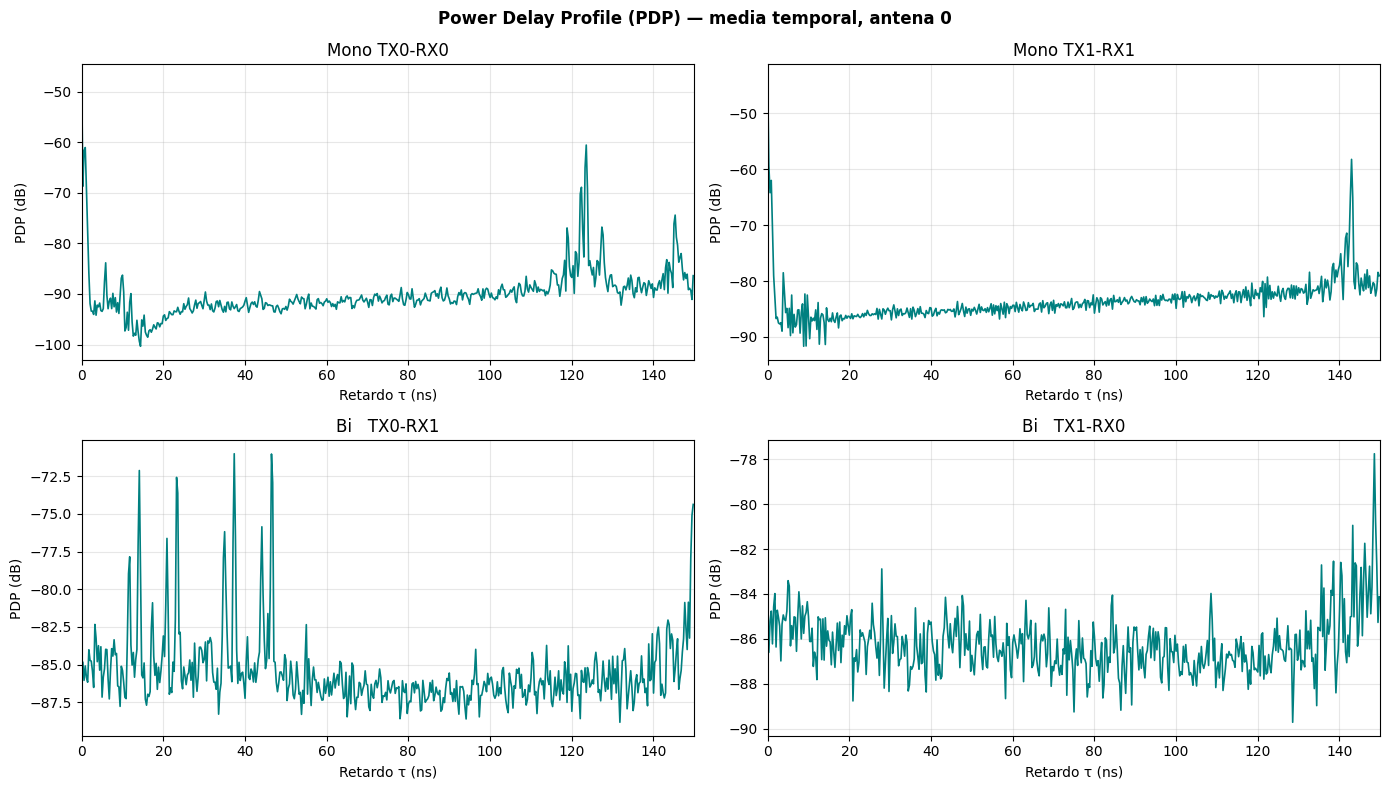

In [7]:
# Visualización del PDP medio (Power Delay Profile = |CIR|² promediado en tiempo)
tau_ns  = tau * 1e9          # ns
tau_lim = 150                # ns — corte de visualización
mask    = tau_ns <= tau_lim

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Power Delay Profile (PDP) — media temporal, antena 0', fontsize=12, fontweight='bold')

for ax, (tx, rx, label) in zip(axes.flat, CONFIGS):
    pdp = np.abs(cir[:, mask, tx, rx, ANT])**2   # (N_t, taps)
    pdp_mean = pdp.mean(axis=0)                   # (taps,)
    pdp_db   = 10 * np.log10(pdp_mean + 1e-12)

    ax.plot(tau_ns[mask], pdp_db, lw=1.2, color='teal')
    ax.set_title(label)
    ax.set_xlabel('Retardo τ (ns)')
    ax.set_ylabel('PDP (dB)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, tau_lim)

plt.tight_layout()
plt.show()

## 5. Split temporal train / val / test

El split se realiza **en orden temporal** (sin mezcla aleatoria) para evitar
data-leakage entre tramas temporalmente correladas.

Proporción: **70% train — 15% val — 15% test**.

In [8]:
splits = split_train_val_test(R_norm, ts, ratios=(0.70, 0.15, 0.15))

for name, sp in splits.items():
    pct = 100 * sp['n_samples'] / N_t
    print(f'{name:5s}: {sp["n_samples"]:>5d} muestras ({pct:.1f}%)'
          f'  t=[{sp["t_start"]:.2f}, {sp["t_end"]:.2f}] s'
          f'  shape={sp["R"].shape}')

total_check = sum(s['n_samples'] for s in splits.values())
assert total_check == N_t, f'Splits no suman N_t: {total_check} ≠ {N_t}'
print(f'\n✓ Suma de splits = {total_check} = N_t = {N_t}')

train:   384 muestras (69.9%)  t=[1773245231677327360.00, 1773245273568673024.00] s  shape=(384, 870, 2, 2, 4)
val  :    82 muestras (14.9%)  t=[1773245273678004992.00, 1773245282546895872.00] s  shape=(82, 870, 2, 2, 4)
test :    83 muestras (15.1%)  t=[1773245282648656128.00, 1773245291759347712.00] s  shape=(83, 870, 2, 2, 4)

✓ Suma de splits = 549 = N_t = 549


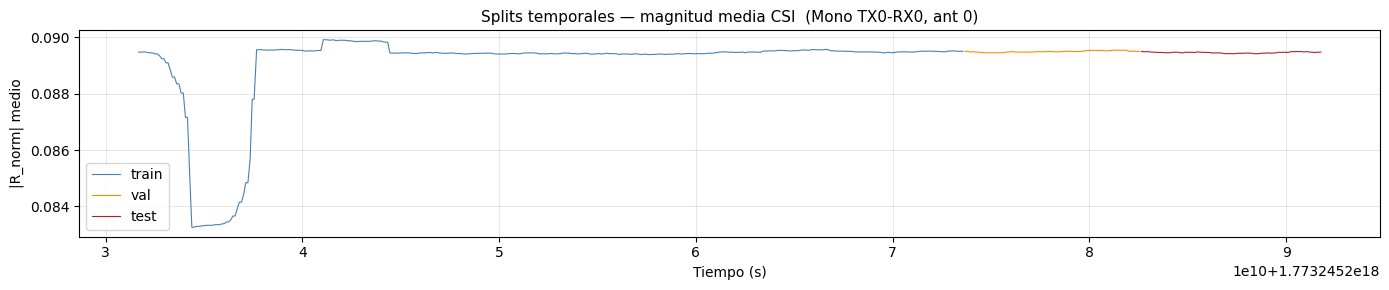

In [9]:
# Visualización de los splits sobre la magnitud media temporal
mag_series = np.abs(R_norm[:, :, 0, 0, ANT]).mean(axis=1)   # (N_t,)

colors = {'train': 'steelblue', 'val': 'darkorange', 'test': 'firebrick'}

fig, ax = plt.subplots(figsize=(14, 3))
ax.set_title('Splits temporales — magnitud media CSI  (Mono TX0-RX0, ant 0)', fontsize=11)
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('|R_norm| medio')

offset = 0
for name, sp in splits.items():
    n = sp['n_samples']
    ax.plot(ts[offset:offset+n], mag_series[offset:offset+n],
            lw=0.8, color=colors[name], label=name)
    offset += n

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Guardado y resumen de shapes

Exportamos los splits a `data/processed/`.  
Cada archivo `.npz` incluye:
- `R_real`, `R_imag` → tensor complejo en dos canales float32
- `R_ri`             → pila Re/Im en último eje `(..., 2)`
- Metadatos de normalización para poder desnormalizar las predicciones

In [10]:
print('Guardando splits CSI en data/processed/ ...')
save_csi_splits(
    splits     = splits,
    frequency  = freq,
    norm_meta  = norm_meta,
    output_dir = DATA_PROC,
    prefix     = 'csi',
)
print('\nFicheros en data/processed:')
for f in sorted(DATA_PROC.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size/1e6:.1f} MB)')

Guardando splits CSI en data/processed/ ...


  ✓ train → csi_train.npz  shape=(384, 870, 2, 2, 4)  (78.8 MB)


  ✓ val   → csi_val.npz  shape=(82, 870, 2, 2, 4)  (16.8 MB)


  ✓ test  → csi_test.npz  shape=(83, 870, 2, 2, 4)  (17.0 MB)

Ficheros en data/processed:
  csi_test.npz  (17.0 MB)
  csi_train.npz  (78.8 MB)
  csi_val.npz  (16.8 MB)
  data_filtered_77.6ghz.npz  (54.1 MB)


In [11]:
# Informe final de shapes para el diseño del FNO
print_csi_report(splits, freq, norm_meta)

  INFORME DE SHAPES — TENSOR CSI
  Frecuencia mín / máx : 77.6022 / 81.0000 GHz
  Subportadoras (N_f)  : 870
  BW                   : 3397.85 MHz
  df                   : 3910.068 kHz
  Normalización        : maxabs

  Split     N_samples      %     t_start       t_end  Shape
  -------- ---------- ------  ----------  ----------  -----
  train           384  69.9%  1773245231677327360.00  1773245273568673024.00  (384, 870, 2, 2, 4)
  val              82  14.9%  1773245273678004992.00  1773245282546895872.00  (82, 870, 2, 2, 4)
  test             83  15.1%  1773245282648656128.00  1773245291759347712.00  (83, 870, 2, 2, 4)

  Tensor input para FNO:
    Complejo    : (384, 870, 2, 2, 4)  dtype=complex64
    Re/Im stack : (384, 870, 2, 2, 4, 2)  dtype=float32


---
## ✅ Resumen

| Paso | Estado |
|------|--------|
| Carga del tensor complejo desde `.npz` | ✓ |
| Verificación de integridad Re²+Im²=|R|² | ✓ |
| Inspección de fase (distribución + evolución temporal) | ✓ |
| Normalización `maxabs` con preservación de fase | ✓ |
| CIR (IFFT compleja) con ventana Hamming | ✓ |
| Split temporal 70/15/15 | ✓ |
| Guardado splits + metadatos normalización | ✓ |

### Próximo paso: `03_FNO_design.ipynb`
Diseño de la arquitectura Fourier Neural Operator usando los splits guardados.